# Insurance Charges Prediction using Machine Learning

Predict insurance charges using Linear Regression.

In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("Shape:", df.shape)
print(df.columns)
df.info()

Shape: (1338, 7)
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [8]:
df.dropna(inplace=True)
print(df.shape)

(1338, 7)


In [9]:
df["sex"]=df["sex"].map({"male":1,"female":0})
df["smoker"]=df["smoker"].map({"yes":1,"no":0})
df["region"]=df["region"].map({
    "southwest":0,
    "southeast":1,
    "northwest":2,
    "northeast":3
})
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


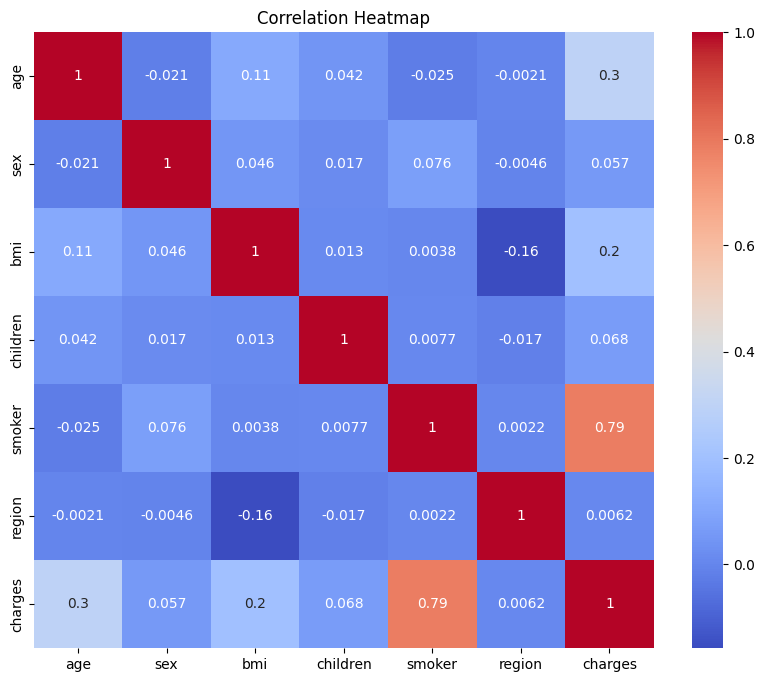

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

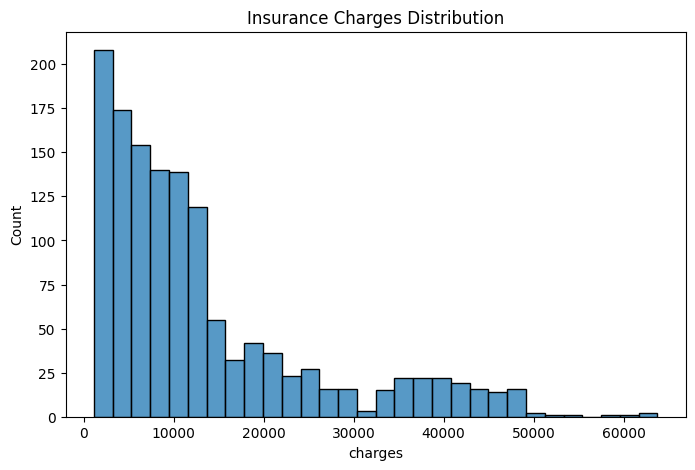

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"],bins=30)
plt.title("Insurance Charges Distribution")
plt.show()

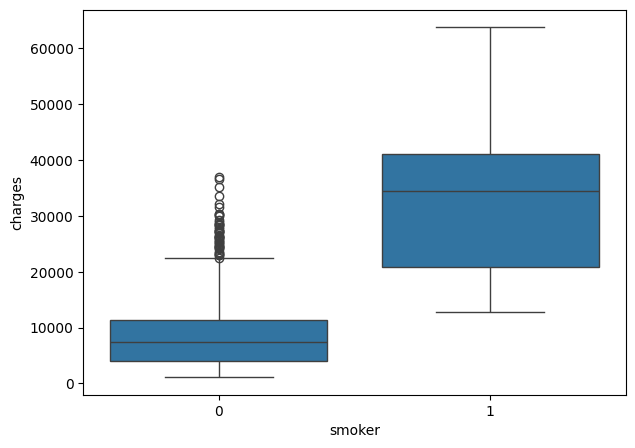

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(x="smoker",y="charges",data=df)
plt.show()

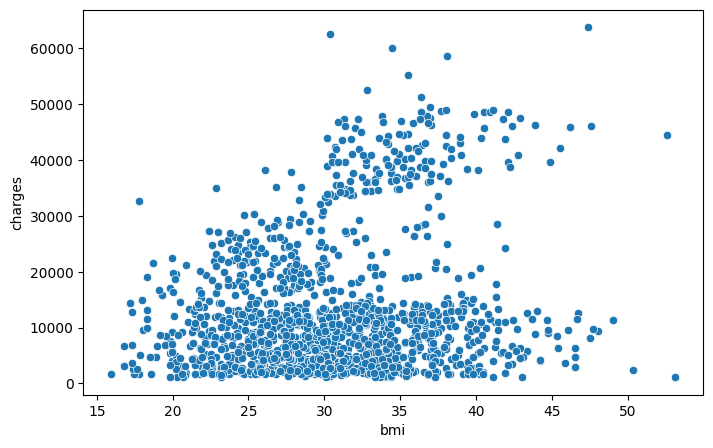

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi",y="charges",data=df)
plt.show()

In [14]:
X=df[["age","sex","bmi","children","smoker","region"]]
y=df["charges"]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [16]:
model=LinearRegression()
model.fit(X_train,y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [17]:
y_pred=model.predict(X_test)
print("R2 Score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score: 0.7833463107364539
MAE: 4186.508898366432
RMSE: 5799.587091438356


In [18]:
comparison=pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})
comparison.head(10)

,Actual,Predicted
764,9095.06825,8924.407244
887,5272.17580,7116.295018
890,29330.98315,36909.013521
1293,9301.89355,9507.874691
259,33750.29180,27013.350008
1312,4536.25900,10790.779562
899,2117.33885,226.298446
752,14210.53595,16942.715999
1286,3732.62510,1056.630794
707,10264.44210,11267.919973


In [19]:
joblib.dump(model,"insurance_model.joblib")
print("Model Saved")

Model Saved


In [21]:
loaded_model=joblib.load("insurance_model.joblib")

In [20]:
def predict_insurance(age,sex,bmi,children,smoker,region):
    sex=1 if sex.lower()=="male" else 0
    smoker=1 if smoker.lower()=="yes" else 0
    region_map={
        "southwest":0,
        "southeast":1,
        "northwest":2,
        "northeast":3
    }
    region=region_map[region.lower()]
    input_df=pd.DataFrame([{
        "age":age,
        "sex":sex,
        "bmi":bmi,
        "children":children,
        "smoker":smoker,
        "region":region
    }])
    prediction=loaded_model.predict(input_df)
    return round(prediction[0],2)

In [22]:
prediction=predict_insurance(
    age=25,
    sex="male",
    bmi=28,
    children=1,
    smoker="no",
    region="northwest"
)
print("Predicted Insurance Charges:",prediction)

Predicted Insurance Charges: 4016.7


In [ ]:
age=int(input("Age: "))
sex=input("Sex (male/female): ")
bmi=float(input("BMI: "))
children=int(input("Children: "))
smoker=input("Smoker (yes/no): ")
region=input("Region: ")

prediction=predict_insurance(
    age,sex,bmi,children,smoker,region
)

print("Predicted Insurance Charges =",prediction)